In [4]:
# Dataset - Downloaded 3 years of daily prices via yfinance
# Used 5–10 assets from different sectors (e.g., AAPL, JPM, TSLA, AMZN, XOM)

import yfinance as yf
tickers = ['AAPL', 'JPM', 'TSLA', 'AMZN', 'XOM']
data = yf.download(tickers, start="2020-01-01", end="2023-12-31")

/tmp/ipython-input-2683637383.py:4: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(tickers, start="2020-01-01", end="2023-12-31")
[*********************100%***********************]  5 of 5 completed


In [10]:
# Check whether data is loaded correctly
print(data)

Price            Close                                                 \
Ticker            AAPL        AMZN         JPM        TSLA        XOM   
Date                                                                    
2020-01-02   72.538498   94.900497  119.573364   28.684000  54.131073   
2020-01-03   71.833267   93.748497  117.995438   29.534000  53.695869   
2020-01-06   72.405678   95.143997  117.901604   30.102667  54.108170   
2020-01-07   72.065155   95.343002  115.897194   31.270666  53.665344   
2020-01-08   73.224411   94.598503  116.801315   32.809334  52.856052   
...                ...         ...         ...         ...        ...   
2023-12-22  191.974670  153.419998  160.106506  252.539993  95.891022   
2023-12-26  191.429306  153.410004  161.053391  256.609985  96.107422   
2023-12-27  191.528442  153.339996  162.019409  261.440002  95.655777   
2023-12-28  191.954865  153.380005  162.880203  253.179993  94.272591   
2023-12-29  190.913651  151.940002  162.688904  248

In [12]:
# DAILY RETURNS
returns = data.pct_change().dropna()
print(returns)

Price          Close                                              High  \
Ticker          AAPL      AMZN       JPM      TSLA       XOM      AAPL   
Date                                                                     
2020-01-03 -0.009722 -0.012139 -0.013196  0.029633 -0.008040 -0.000067   
2020-01-06  0.007969  0.014886 -0.000795  0.019255  0.007678 -0.002062   
2020-01-07 -0.004703  0.002092 -0.017001  0.038801 -0.008184  0.003134   
2020-01-08  0.016086 -0.007809  0.007801  0.049205 -0.015080  0.011765   
2020-01-09  0.021241  0.004799  0.003651 -0.021945  0.007656  0.019675   
...              ...       ...       ...       ...       ...       ...   
2023-12-22 -0.005548 -0.002730 -0.000597 -0.007701  0.001770 -0.008474   
2023-12-26 -0.002841 -0.000065  0.005914  0.016116  0.002257 -0.007778   
2023-12-27  0.000518 -0.000456  0.005998  0.018822 -0.004699 -0.002012   
2023-12-28  0.002226  0.000261  0.005313 -0.031594 -0.014460  0.005995   
2023-12-29 -0.005424 -0.009388 -0.0011

In [13]:
# PORTFOLIO RETURNS - assumed equal weights
weights = [1/len(returns.columns)] * len(returns.columns)
portfolio_returns = returns.dot(weights)

In [14]:
# PARAMETRIC VaR (Variance and Covariance Approach) - For 95% and 99% confidence
import scipy.stats as stats

mean = portfolio_returns.mean()
std_dev = portfolio_returns.std()

VaR_95 = stats.norm.ppf(0.05, mean, std_dev)
VaR_99 = stats.norm.ppf(0.01, mean, std_dev)

In [15]:
# HISTORICAL VaR
VaR_hist_95 = portfolio_returns.quantile(0.05)
VaR_hist_99 = portfolio_returns.quantile(0.01)

In [16]:
# EXPECTED SHORTFALL (CVaR)
CVaR_95 = portfolio_returns[portfolio_returns <= VaR_hist_95].mean()
CVaR_99 = portfolio_returns[portfolio_returns <= VaR_hist_99].mean()

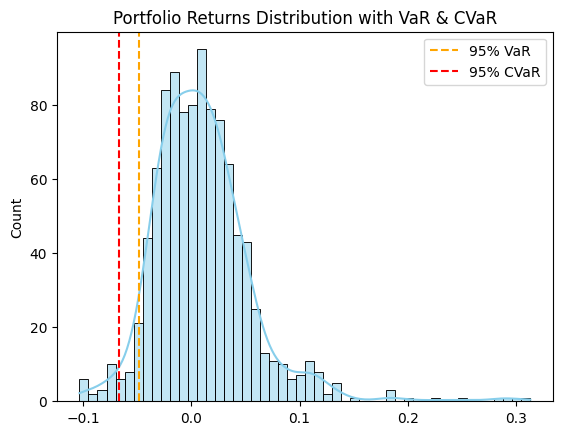

In [17]:
# VISUALIZE VaR and CVaR
import matplotlib.pyplot as plt
import seaborn as sns

sns.histplot(portfolio_returns, bins=50, kde=True, color='skyblue')
plt.axvline(VaR_hist_95, color='orange', linestyle='--', label='95% VaR')
plt.axvline(CVaR_95, color='red', linestyle='--', label='95% CVaR')
plt.legend()
plt.title('Portfolio Returns Distribution with VaR & CVaR')
plt.show()

In [18]:
# BACKTESTING - Compared actual losses vs. predicted VaR
breaches = portfolio_returns[portfolio_returns < VaR_hist_99]
num_breaches = breaches.count()
print(f"99% VaR breaches: {num_breaches} out of {len(portfolio_returns)} days")

99% VaR breaches: 11 out of 1005 days


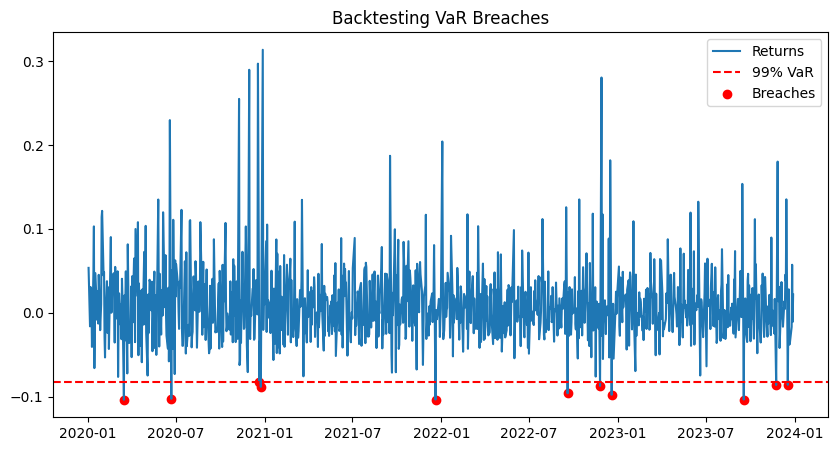

In [19]:
# VISUALIZE Backtesting VaR Breaches
plt.figure(figsize=(10,5))
plt.plot(portfolio_returns.index, portfolio_returns, label='Returns')
plt.axhline(VaR_hist_99, color='red', linestyle='--', label='99% VaR')
plt.scatter(breaches.index, breaches, color='red', label='Breaches')
plt.legend()
plt.title('Backtesting VaR Breaches')
plt.show()

In [20]:
# RESULTS / METRICS
metrics = {
    'Metric': ['Parametric VaR', 'Historical VaR', 'Expected Shortfall'],
    '95%': [VaR_95, VaR_hist_95, CVaR_95],
    '99%': [VaR_99, VaR_hist_99, CVaR_99]
}

import pandas as pd
results_df = pd.DataFrame(metrics)
results_df = results_df.applymap(lambda x: f"{x*100:.2f}%" if isinstance(x, float) else x)
print(results_df)

               Metric     95%     99%
0      Parametric VaR  -6.56%  -9.69%
1      Historical VaR  -4.81%  -8.18%
2  Expected Shortfall  -6.70%  -9.41%


/tmp/ipython-input-2170512363.py:10: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  results_df = results_df.applymap(lambda x: f"{x*100:.2f}%" if isinstance(x, float) else x)
